# import Libraries

In [2]:
!pip install sqlalchemy

^C


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Spotify Song Popularity Prediction

This project uses a Spotify dataset (6300 songs) to predict song popularity based on 
the available features (genre, duration, explicit flag).

**Steps:** Data Cleaning → Exploratory Data Analysis → Model Training (Random Forest) → 
Feature Importance → SQLAlchemy Database Storage

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
from sqlalchemy import create_engine






 # Data Overview

In [4]:
Spotify_Dataset=pd.read_csv("spotify dataset.zip")
print(Spotify_Dataset)

                          id                                           name  \
0     7kr3xZk4yb3YSZ4VFtg2Qt                                       Acoustic   
1     1kJygfS4eoVziBBI93MSYp                                       Acoustic   
2     6lynns69p4zTCRxmmiSY1x                  Here Comes the Sun - Acoustic   
3     1RC9slv335IfLce5vt9KTW                                    Acoustic #3   
4     5o9L8xBuILoVjLECSBi7Vo  My Love Mine All Mine - Acoustic Instrumental   
...                      ...                                            ...   
6295  4uveHSzaz8YEbTF9j6QlCI                             Voyage to Atlantis   
6296  4u15cjyziW2Ewn5Ek3082l                                       L'Oiseau   
6297  56pHPaTeX2O9aVmTFYS8hV                                   The Daintree   
6298  6Ldyc5TsR4kaUsuHKcB2AD                         The Sorcerers Symphony   
6299  3ry0f8ybk8upUBIk8unvmF                                Fiore d'inverno   

            genre                                  

In [5]:
Spotify_Dataset.shape

(6300, 8)

In [6]:
Spotify_Dataset.size

50400

In [7]:
Spotify_Dataset.columns

Index(['id', 'name', 'genre', 'artists', 'album', 'popularity', 'duration_ms',
       'explicit'],
      dtype='object')

In [8]:
Spotify_Dataset.head()

,id,name,genre,artists,album,popularity,duration_ms,explicit
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,acoustic,Billy Raffoul,1975,58,172199,False
1,1kJygfS4eoVziBBI93MSYp,Acoustic,acoustic,Billy Raffoul,A Few More Hours at YYZ,57,172202,False
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),42,144786,False
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,acoustic,The Goo Goo Dolls,Dizzy up the Girl,46,116573,False
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,acoustic,"Guus Dielissen, Casper Esmann",My Love Mine All Mine (Acoustic Instrumental),33,133922,False


In [9]:
Spotify_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           6300 non-null   object
 1   name         6300 non-null   object
 2   genre        6300 non-null   object
 3   artists      6300 non-null   object
 4   album        6300 non-null   object
 5   popularity   6300 non-null   int64 
 6   duration_ms  6300 non-null   int64 
 7   explicit     6300 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 350.8+ KB


In [10]:
Spotify_Dataset.isnull().sum()

id             0
name           0
genre          0
artists        0
album          0
popularity     0
duration_ms    0
explicit       0
dtype: int64

In [11]:
Spotify_Dataset['artists'].unique()

array(['Billy Raffoul', 'Molly Hocking, Bailey Rushlow',
       'The Goo Goo Dolls', ..., 'World Music Atelier',
       'Putumayo, Marianne Perrudin, Thomas Artaud',
       'Putumayo, Giacomo Lariccia'], shape=(4651,), dtype=object)

In [12]:
Spotify_Dataset['artists'].value_counts()

artists
Metallica                     22
ONE OK ROCK                   20
Chicago House Selection       18
Death                         17
Progressive House Sessions    16
                              ..
Cody Fry                       1
SLANDER, Dylan Matthew         1
Lesfm, Olexy                   1
The Moon Loungers              1
BradBrooks, Pamela Bravo       1
Name: count, Length: 4651, dtype: int64

In [13]:
Spotify_Dataset = Spotify_Dataset.drop_duplicates()
print("Duplicates removed. New shape:", Spotify_Dataset.shape)

Duplicates removed. New shape: (6300, 8)


In [14]:
Spotify_Dataset.nunique()

id             6187
name           4518
genre           126
artists        4651
album          4949
popularity       90
duration_ms    5566
explicit          2
dtype: int64

In [15]:
Spotify_Dataset['popularity'].mean()

np.float64(30.754761904761907)

In [16]:
artist_popularity=Spotify_Dataset.groupby("artists")["popularity"].mean().reset_index()
print(artist_popularity)

                       artists  popularity
0          "Weird Al" Yankovic        40.0
1                $anto, Satsu¿        20.0
2          $tupid Young, Mozzy        47.0
3     $uicideboy$, Black Smurf        48.0
4          (((()))), surround.        33.0
...                        ...         ...
4646                      鈴木 弘        44.0
4647                     闻人听書_        49.0
4648                       陶晶瑩        48.0
4649                       黃小琥        39.0
4650                       서이브        47.0

[4651 rows x 2 columns]


 # Data Visualization 

The correlation heatmap shows a weak correlation between the numerical feature 
(duration_ms) and popularity — meaning duration alone isn't enough to predict popularity.

Feature Correlation Heatmap


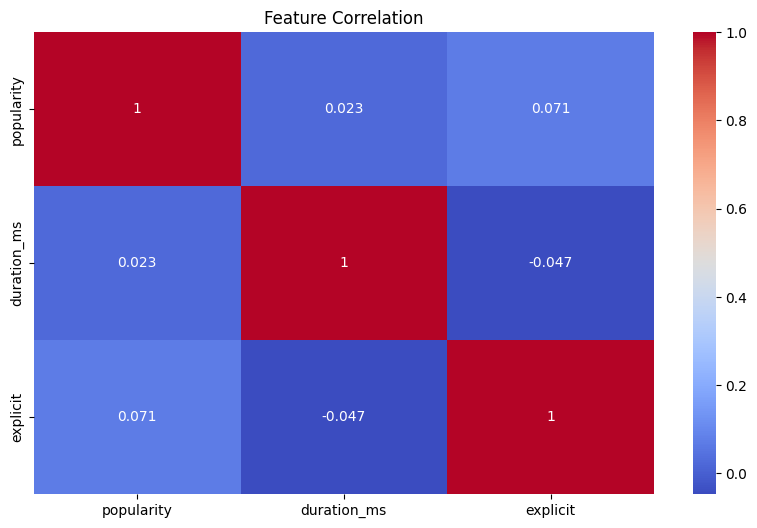

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(Spotify_Dataset.corr(numeric_only=True), 
            annot=True, 
            cmap="coolwarm")

plt.title("Feature Correlation")
plt.show()

Popularity Distribution

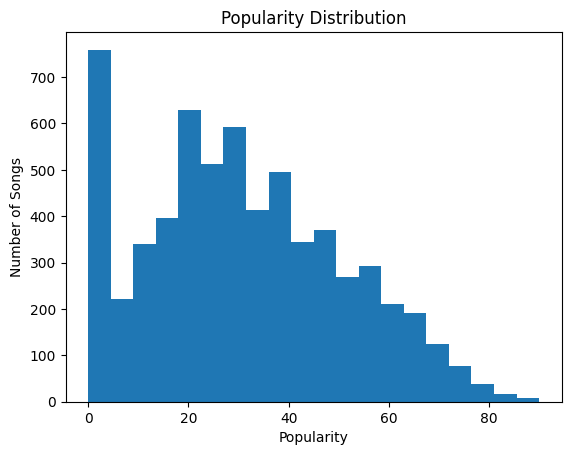

In [18]:
plt.figure()

plt.hist(Spotify_Dataset["popularity"], bins=20)

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

## Top 10 Artists by Average Popularity

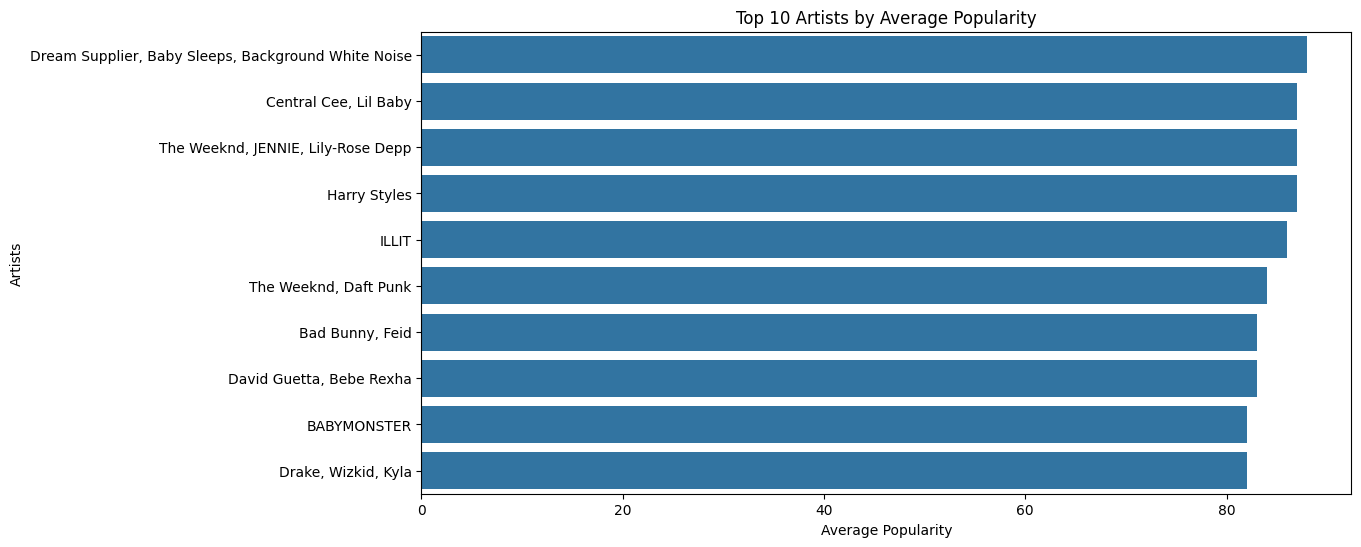

In [19]:
top_artists = (
    Spotify_Dataset.groupby('artists')['popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_artists,
    x='popularity',
    y='artists'
)

plt.title("Top 10 Artists by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Artists")
plt.show()

####  Duration vs Popularity 

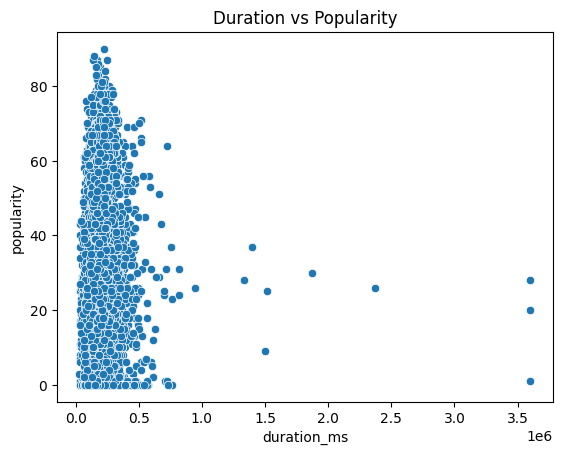

In [20]:
sns.scatterplot(data=Spotify_Dataset,x="duration_ms",y="popularity")
plt.title("Duration vs Popularity")
plt.show()



###### Popularity of genres

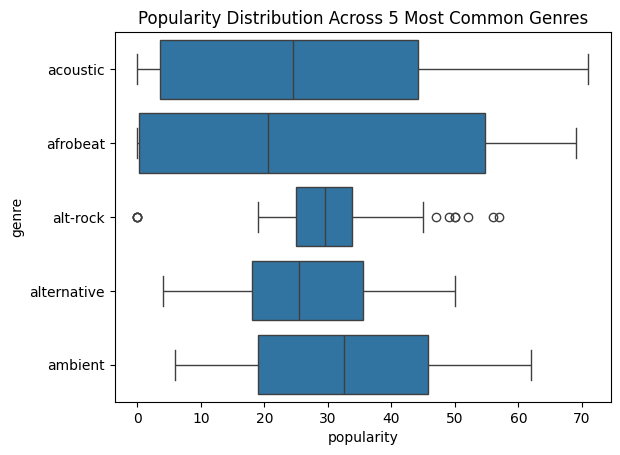

In [21]:
top_genres=Spotify_Dataset['genre'].value_counts().head().index
sns.boxplot(
    data=Spotify_Dataset[Spotify_Dataset['genre'].isin(top_genres)],
    x='popularity',
    y='genre'
)
plt.title("Popularity Distribution Across 5 Most Common Genres")
plt.show()

##### Explicit vs non-explicit Popularity

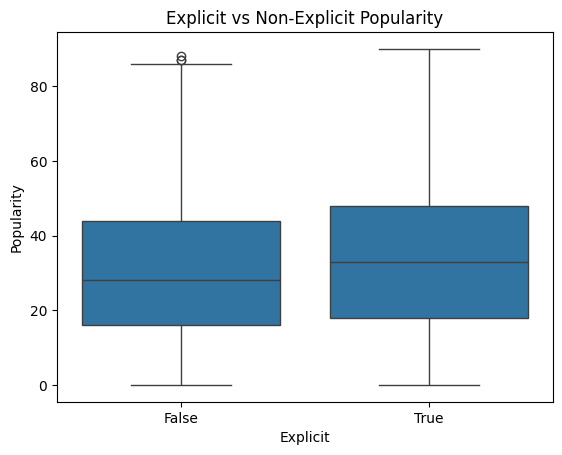

In [22]:
sns.boxplot(
    data=Spotify_Dataset,
    x='explicit',
    y='popularity'
)

plt.title("Explicit vs Non-Explicit Popularity")
plt.xlabel("Explicit")
plt.ylabel("Popularity")
plt.show()

# Model Training

The features (`genre`, `duration_ms`, `explicit`) were selected for the model, since the 
remaining columns (`id`, `name`, `artists`, `album`) weren't directly useful for prediction 
(unique identifiers or high-cardinality text columns).

A Random Forest Regressor was used, and `max_depth` and `min_samples_leaf` were tuned 
to reduce overfitting.

In [18]:
numeric_feature=['duration_ms']
categorical_features = ['genre', 'explicit']
X = Spotify_Dataset[numeric_feature + categorical_features]
y = Spotify_Dataset['popularity']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_feature),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [37]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42
    ))
])

In [38]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Feature importance shows `duration_ms` as the most influential feature for the model, 
followed by the effect of a few specific genres.

In [39]:
predictions = pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))


R2 Score: 0.1907275146426196
RMSE: 18.040105617796026


In [40]:
train_predictions = pipeline.predict(X_train)
print("Train R2:", r2_score(y_train, train_predictions))
print("Test R2:", r2_score(y_test, predictions))

Train R2: 0.273498468856579
Test R2: 0.1907275146426196


In [41]:
importances = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

print(importance_df)

                          feature  importance
0                num__duration_ms    0.239338
100               cat__genre_rock    0.062463
22               cat__genre_dance    0.061476
87                 cat__genre_pop    0.057601
117             cat__genre_summer    0.052450
..                            ...         ...
85     cat__genre_philippines-opm    0.000000
109  cat__genre_singer-songwriter    0.000000
99           cat__genre_road-trip    0.000000
120              cat__genre_tango    0.000000
125           cat__genre_work-out    0.000000

[129 rows x 2 columns]


In [42]:
joblib.dump(pipeline, 'spotify_popularity_model.pkl')

['spotify_popularity_model.pkl']

## 5. Storing Data in  Database

In [43]:


engine = create_engine('sqlite:///spotify.db')

Spotify_Dataset.to_sql('songs', engine, if_exists='replace', index=False)

6300

In [44]:
query = "SELECT * FROM songs LIMIT 10"
result = pd.read_sql(query, engine)
print(result)

                       id                                           name  \
0  7kr3xZk4yb3YSZ4VFtg2Qt                                       Acoustic   
1  1kJygfS4eoVziBBI93MSYp                                       Acoustic   
2  6lynns69p4zTCRxmmiSY1x                  Here Comes the Sun - Acoustic   
3  1RC9slv335IfLce5vt9KTW                                    Acoustic #3   
4  5o9L8xBuILoVjLECSBi7Vo  My Love Mine All Mine - Acoustic Instrumental   
5  742ZnC1OgUGIScdzXEy5ui                                       Acoustic   
6  3vpJdk93GzerZnlou6Ua0z                    Beautiful Things - Acoustic   
7  42qGA2116mkpSAaxzQfjEf                                      Landslide   
8  0OHHcoyrWnkVukc911UeZd                                       Acoustic   
9  64zEnxASl3epPAIH4MsmSw                     Acoustic Energy Vibrations   

      genre                                       artists  \
0  acoustic                                 Billy Raffoul   
1  acoustic                              

In [45]:
results_df = X_test.copy()
results_df['actual_popularity'] = y_test.values
results_df['predicted_popularity'] = predictions

results_df.to_sql('predictions', engine, if_exists='replace', index=False)

1260

## Conclusion

The model achieves an R² score of approximately 19%–27%, indicating limited predictive performance.
This is largely due to the limited features available in the dataset ('genre', 'duration_ms', 'explicit') — major real-world drivers of popularity such as artist fame, stream counts, and audio features (energy, danceability) are not included in this dataset.

**Future improvements**: Adding audio features or artist popularity metrics to the dataset could significantly improve model performance.